# LangGraph Single-turn Chatbot

In [2]:
%pip install langgraph -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## State
agent간에 공유될 정보를 State 개체(dict)로써 관리

In [ ]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

## 챗봇 노드
- Node(Agent) function
- Edge

In [ ]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-5.6-luna')

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

## 그래프 설계 / 컴파일

<class 'langgraph.graph.state.CompiledStateGraph'>


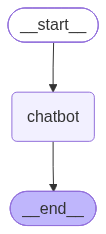

In [ ]:
# START -> chatbot -> END로 동작하는 LangGraph 설계
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성

workflow.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드
workflow.add_node('chatbot', chatbot)  # chatbot 노드
workflow.add_edge('chatbot', END)    # chatbot -> 종료 노드

graph = workflow.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일
print(type(graph))  # 그래프 타입 확인

graph  # 그래프 객체

In [ ]:
user_query = '랭그래프가 뭐죠?'

# messages는 add_messages 규칙에 따라 계속해서 누적됨
state = {
    'messages': [
        ('system', '당신은 현명한 IT전문가 입니다.'),
        ('human', user_query)
    ]
}

response = graph.invoke(state)  # 그래프 실행(START -> chatbot -> END)
print(response)  # 최종 누적 완료된 상태

{'messages': [SystemMessage(content='당신은 현명한 IT전문가 입니다.', additional_kwargs={}, response_metadata={}, id='839f6c26-b54b-49cb-8006-408e4579e766'), HumanMessage(content='랭그래프가 뭐죠?', additional_kwargs={}, response_metadata={}, id='5ffad43b-236e-4fcf-98a2-e00ccf91cfb9'), AIMessage(content='랭그래프(LangGraph)는 **LLM 기반 에이전트와 복잡한 작업 흐름을 그래프 형태로 설계·실행하는 오픈소스 프레임워크**입니다. LangChain 생태계에서 만들어졌지만, LangChain과 함께 또는 별도로 사용할 수 있습니다.\n\n### 핵심 개념\n\n- **노드(Node)**: 실행할 작업  \n  예: LLM 호출, 검색, 데이터베이스 조회, 도구 실행\n- **엣지(Edge)**: 작업 간 이동 경로\n- **상태(State)**: 대화 내용, 검색 결과, 작업 진행 상황 등 여러 단계에서 공유하는 데이터\n- **조건 분기**: 결과에 따라 다음 작업을 다르게 실행\n- **반복 루프**: 답변을 검토하고 부족하면 다시 생성\n- **체크포인트**: 실행 상태를 저장해 중단 후 재개\n- **사람 개입(Human-in-the-loop)**: 특정 단계에서 사용자의 승인이나 수정 반영\n\n예를 들어 문서 질의응답 에이전트를 만든다면 다음처럼 구성할 수 있습니다.\n\n```text\n사용자 질문\n   ↓\n질문 분석\n   ↓\n문서 검색\n   ↓\n답변 생성\n   ↓\n답변 검토 ── 부족함 → 추가 검색\n   ↓\n최종 답변\n```\n\n단순한 LLM 호출은 일반적으로 다음처럼 직선적입니다.\n\n```text\n입력 → 프롬프트 → LLM → 출력\n```\n\n반면 LangGraph는 다음과 같은 복잡한 흐름에 적합합니

In [ ]:
print(response['messages'][-1].content)  # 누적된 messages 중 마지막(모델 응답) 내용 출력

랭그래프(LangGraph)는 **LLM 기반 에이전트와 복잡한 작업 흐름을 그래프 형태로 설계·실행하는 오픈소스 프레임워크**입니다. LangChain 생태계에서 만들어졌지만, LangChain과 함께 또는 별도로 사용할 수 있습니다.

### 핵심 개념

- **노드(Node)**: 실행할 작업  
  예: LLM 호출, 검색, 데이터베이스 조회, 도구 실행
- **엣지(Edge)**: 작업 간 이동 경로
- **상태(State)**: 대화 내용, 검색 결과, 작업 진행 상황 등 여러 단계에서 공유하는 데이터
- **조건 분기**: 결과에 따라 다음 작업을 다르게 실행
- **반복 루프**: 답변을 검토하고 부족하면 다시 생성
- **체크포인트**: 실행 상태를 저장해 중단 후 재개
- **사람 개입(Human-in-the-loop)**: 특정 단계에서 사용자의 승인이나 수정 반영

예를 들어 문서 질의응답 에이전트를 만든다면 다음처럼 구성할 수 있습니다.

```text
사용자 질문
   ↓
질문 분석
   ↓
문서 검색
   ↓
답변 생성
   ↓
답변 검토 ── 부족함 → 추가 검색
   ↓
최종 답변
```

단순한 LLM 호출은 일반적으로 다음처럼 직선적입니다.

```text
입력 → 프롬프트 → LLM → 출력
```

반면 LangGraph는 다음과 같은 복잡한 흐름에 적합합니다.

```text
입력 → 판단 → 검색 → 도구 실행 → 검토 → 재시도 또는 완료
```

### LangChain과의 차이

- **LangChain**: LLM, 프롬프트, 검색기, 도구 등을 연결하는 구성 요소와 체인 제공
- **LangGraph**: 이러한 구성 요소를 이용해 **상태를 유지하는 복잡한 에이전트 흐름**을 그래프로 관리

즉, LangChain이 “부품과 기본 연결 방식”이라면 LangGraph는 “분기·반복·상태 관리가 가능한 워크플로 엔진”에 가깝습니다.

### 언제 사용하면 좋은가요?

다음과 같은 경우에 유용합니다.

- 여러 단